# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Calabozo, Nicolas Daniel
- Alumno 2 : Lapolla, Martín Facundo

## Librerías

In [ ]:
# --- Librerías estándar --
import os
import random
import numpy as np
import cv2
import ssl
import time
import uuid
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import copy
from tqdm import tqdm
from collections import Counter
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# -- PyTorch y librerías relacionadas --
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from torchvision import datasets
from facenet_pytorch import MTCNN, InceptionResnetV1
import torch.nn.functional as F


# -- Scikit-learn --
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# -- Configuración para evitar problemas de SSL al descargar el dataset --
ssl._create_default_https_context = ssl._create_unverified_context

# -- Importación de clases personalizadas para el manejo de base de datos vectorial --
import sys
sys.path.append(os.path.abspath('./src'))
from lib.storage.pgvector_store import PgVectorEmbeddingStore
from lib.schemas import EmbeddingRecord

#-- Cargar variables de entorno --
load_dotenv(dotenv_path="./src/.env")

# -- Configuración del dispositivo (GPU si está disponible, sino CPU) --
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

python-dotenv could not parse statement starting at line 9
python-dotenv could not parse statement starting at line 19
python-dotenv could not parse statement starting at line 21


Usando dispositivo: cpu


Para poder interactuar con la base de datos vectorial (PGVector), necesitamos crear una instancia de la clase provista por la cátedra PgVectorEmbeddingStore. Para ello, recuperamos los valores de inicialización desde el entorno de desarrollo (.env)

In [2]:
#Setup de BBDD vectorial 
store = PgVectorEmbeddingStore(
    dbname=os.getenv("POSTGRES_DB","faces"),
    user=os.getenv("POSTGRES_USER", "faces_user"),
    password=os.getenv("POSTGRES_PASSWORD", "faces_pass"),
    host=os.getenv("POSTGRES_HOST", "localhost"),
    port=int(os.getenv("POSTGRES_PORT", "5432")),
    embedding_dim=int(os.getenv("EMBEDDING_DIM", 512))
)
# Limpiar la tabla de embeddings antes de insertar nuevos datos
store.truncate() 
print("Tabla de embeddings limpia. Lista para insertar nuevos datos.")

Tabla de embeddings limpia. Lista para insertar nuevos datos.


### 1. Preprocesamiento

#### Dataset LFW (Labelled Faces in the Wild)

Seleccionamos LFW (Labelled Faces in The Wild) como dataset complementario al propio, ya que su propósito se alinea con el nuestro, fue creado para realizar proyectos orientados al reconocimiento facial y etiquetado de las mismas mediante diferentes modelos basados en redes neuronales o transformers.

In [3]:
# -- Descarga del dataset LFW (Labeled Faces in the Wild) --
lfw_data = fetch_lfw_people(
    min_faces_per_person=20,
    color=True,
    resize=1.0,
    slice_=None, #type: ignore
    download_if_missing=True)
print("Descarga completa - Imágenes sin recortar, a color, tamaño 250x250")


Descarga completa - Imágenes sin recortar, a color, tamaño 250x250


--------------------------------------------------
RESUMEN ESTADÍSTICO: LFW (min_faces_per_person=20)
--------------------------------------------------
Total de imágenes:          3023
Total de clases (personas): 62
Promedio de fotos/persona:  48.76
Desviación Estándar:        70.51
Mínimo de fotos/persona:    20
Máximo de fotos/persona:    530
--------------------------------------------------

ANÁLISIS DE DESBALANCE:
Persona                   | Fotos
-----------------------------------
George W Bush             | 530   (Clase Mayoritaria)
Colin Powell              | 236   (Clase Mayoritaria)
Tony Blair                | 144   (Clase Mayoritaria)
Donald Rumsfeld           | 121   (Clase Mayoritaria)
Gerhard Schroeder         | 109   (Clase Mayoritaria)
...
Angelina Jolie            | 20    (Clase Minoritaria)
Jiang Zemin               | 20    (Clase Minoritaria)
Igor Ivanov               | 20    (Clase Minoritaria)
Michael Bloomberg         | 20    (Clase Minoritaria)
Paul Bremer     

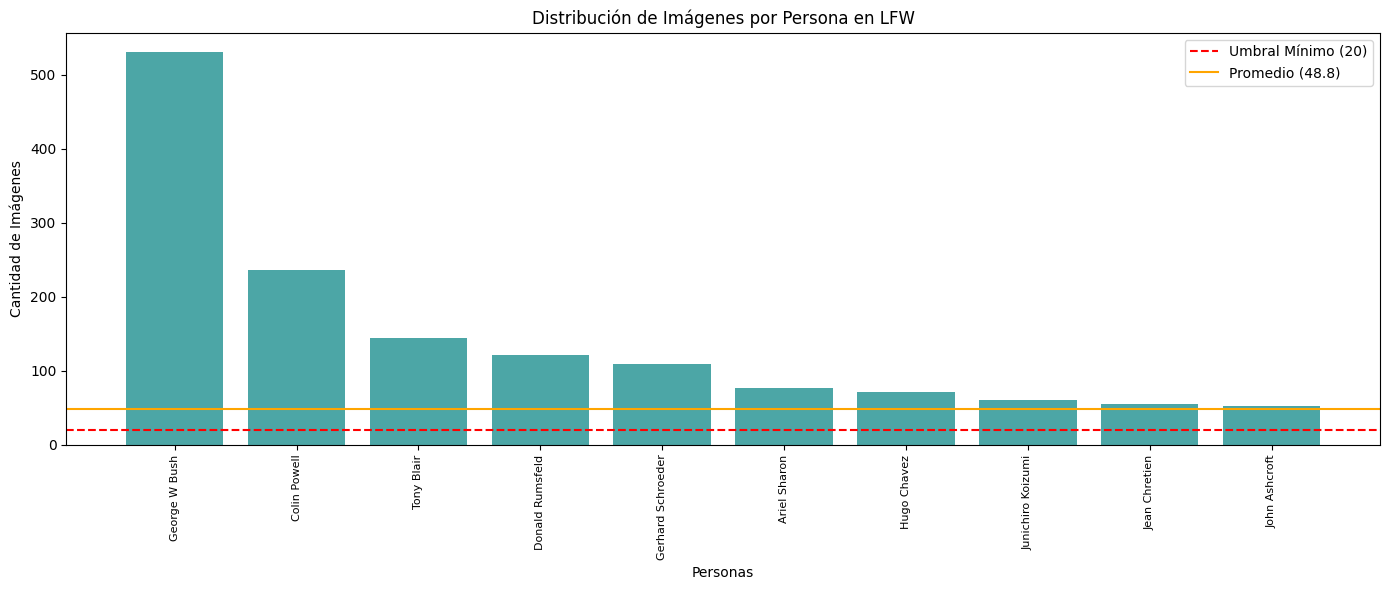

In [ ]:
#Calcular frecuencias de cada persona
counts = Counter(lfw_data.target) #type: ignore
names = lfw_data.target_names #type: ignore

#Mapear nombres a sus conteos y ordenar de mayor a menor
class_counts = {names[i]: count for i, count in counts.items()}
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

#Cálculo de Medidas Resumen
total_images = len(lfw_data.images) #type: ignore
total_classes = len(names)
counts_val = list(counts.values())
min_imgs = np.min(counts_val)
max_imgs = np.max(counts_val)
mean_imgs = np.mean(counts_val)
std_imgs = np.std(counts_val)

#Reporte
print("-" * 50)
print(f"RESUMEN ESTADÍSTICO: LFW (min_faces_per_person=20)")
print("-" * 50)
print(f"Total de imágenes:          {total_images}")
print(f"Total de clases (personas): {total_classes}")
print(f"Promedio de fotos/persona:  {mean_imgs:.2f}")
print(f"Desviación Estándar:        {std_imgs:.2f}")
print(f"Mínimo de fotos/persona:    {min_imgs}")
print(f"Máximo de fotos/persona:    {max_imgs}")
print("-" * 50)

print("\nANÁLISIS DE DESBALANCE:")
print(f"{'Persona':<25} | {'Fotos':<5}")
print("-" * 35)
for name, count in sorted_counts[:5]:
    print(f"{name:<25} | {count:<5} (Clase Mayoritaria)")
print("...")
for name, count in sorted_counts[-5:]:
    print(f"{name:<25} | {count:<5} (Clase Minoritaria)")

Ya que hay un desbalance de clases notorio, decidimos realizar un undersampling, quedándonos solamente con veinte fotos por clase

In [6]:
np.random.seed(42)

max_ph_per_person = 10
balanced_idx = []

# Obtenemos todos los identificadores únicos (IDs numéricos)
unique_classes = np.unique(lfw_data.target) #type: ignore

for class_ in unique_classes:
    #Encontramos todos los índices donde aparece la persona
    class_idx = np.where(lfw_data.target == class_)[0] #type: ignore
    
    #Si la persona tiene más de 10 fotos, aplicamos undersampling
    if len(class_idx) > max_ph_per_person:
        #Elegimos 10 índices al azar
        selected_idx = np.random.choice(class_idx, max_ph_per_person, replace=False)
    else:
        #Si tiene 10 o menos, nos quedamos con todas.
        #Como explicitamos mediante el método lfw_fetch_people que queremos personas con al menos 10 fotos, esto no debería pasar
        selected_idx = class_idx
        
    #Guardamos los índices seleccionados para la persona
    balanced_idx.extend(selected_idx)

#Convertimos la lista a un arreglo de numpy
balanced_idx = np.array(balanced_idx)

# Mezclamos los índices finales. 
# Si no lo hacemos, el dataset quedará ordenado por persona, lo cual es malo para el entrenamiento.
np.random.shuffle(balanced_idx)

#Filtramos los arreglos originales usando los nuevos índices
balanced_imgs = lfw_data.images[balanced_idx] #type: ignore
balanced_labels = lfw_data.target[balanced_idx] #type: ignore

# Resumen
print(f"Total de imágenes original: {len(lfw_data.images)}") #type: ignore
print(f"Total de imágenes balanceado: {len(balanced_imgs)}")

# Verificación
_, counts = np.unique(balanced_labels, return_counts=True)
print(f"Máximo de fotos para una persona ahora: {counts.max()}")

Total de imágenes original: 3023
Total de imágenes balanceado: 620
Máximo de fotos para una persona ahora: 10


In [7]:
#Para observar el balance, imprimimos un resumen con el nombre de cada persona y la cantidad de fotos que tiene en el dataset balanceado.
unique_balanced_classes, counts = np.unique(balanced_labels, return_counts=True)
balanced_names = lfw_data.target_names[unique_balanced_classes] # type: ignore
combined_data = zip(balanced_names, counts)

print(f"\n--- Resumen del Dataset Balanceado ({len(balanced_names)} personas en total) ---")

for i, (name, quantity) in enumerate(combined_data):
    text = f"{name}: {quantity} fotos"
    print(f"{text:<35}", end="")
    if (i + 1) % 3 == 0:
        print()
if len(balanced_names) % 3 != 0:
    print()


--- Resumen del Dataset Balanceado (62 personas en total) ---
Alejandro Toledo: 10 fotos         Alvaro Uribe: 10 fotos             Amelie Mauresmo: 10 fotos          
Andre Agassi: 10 fotos             Angelina Jolie: 10 fotos           Ariel Sharon: 10 fotos             
Arnold Schwarzenegger: 10 fotos    Atal Bihari Vajpayee: 10 fotos     Bill Clinton: 10 fotos             
Carlos Menem: 10 fotos             Colin Powell: 10 fotos             David Beckham: 10 fotos            
Donald Rumsfeld: 10 fotos          George Robertson: 10 fotos         George W Bush: 10 fotos            
Gerhard Schroeder: 10 fotos        Gloria Macapagal Arroyo: 10 fotos  Gray Davis: 10 fotos               
Guillermo Coria: 10 fotos          Hamid Karzai: 10 fotos             Hans Blix: 10 fotos                
Hugo Chavez: 10 fotos              Igor Ivanov: 10 fotos              Jack Straw: 10 fotos               
Jacques Chirac: 10 fotos           Jean Chretien: 10 fotos            Jennifer Aniston: 1

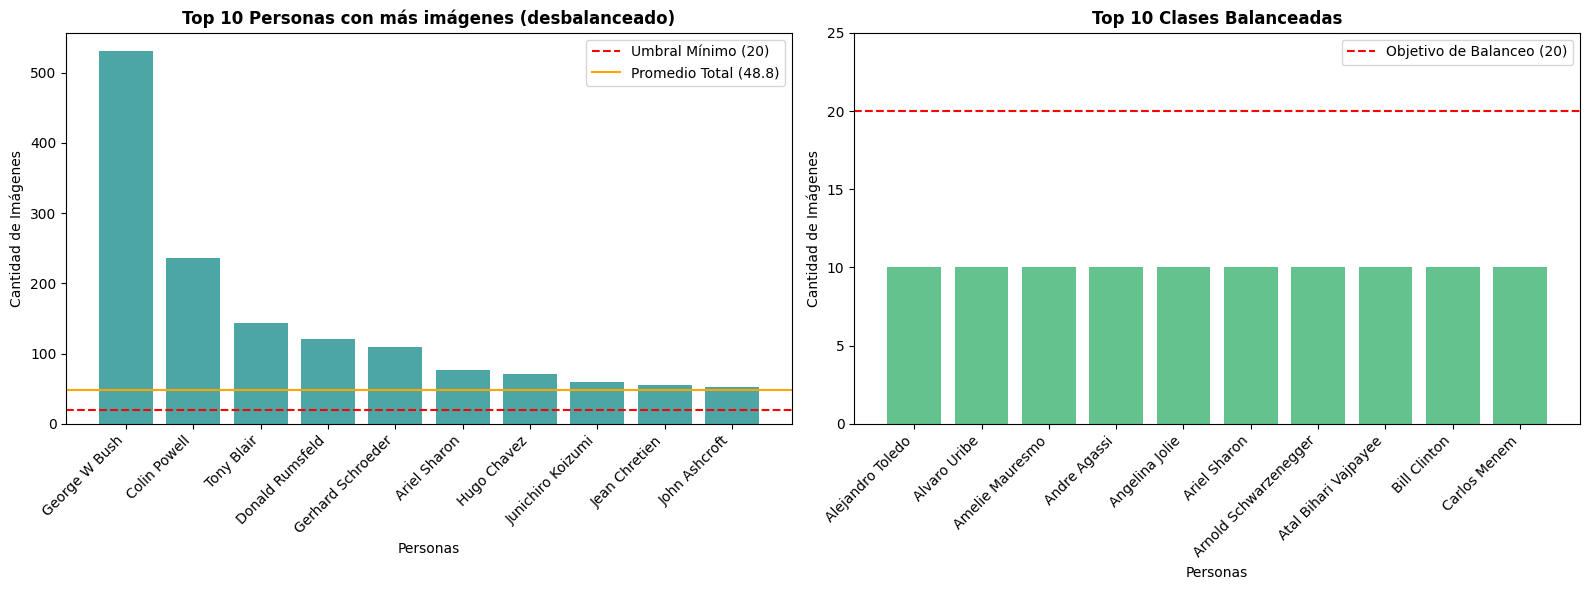

In [45]:
# Ordenamos los datos balanceados para sacar el Top 10
sorted_combined_data = sorted(combined_data, key=lambda x: x[1], reverse=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dataset Original (Desbalanceado)
labels_orig, values_orig = zip(*sorted_counts[:10]) # Asume que sorted_counts sigue en memoria
axes[0].bar(labels_orig, values_orig, color='teal', alpha=0.7)
axes[0].axhline(y=20, color='red', linestyle='--', label='Umbral Mínimo (20)')

if 'mean_imgs' in globals() or 'mean_imgs' in locals():
    axes[0].axhline(y=float(mean_imgs), color='orange', linestyle='-', label=f'Promedio Total ({mean_imgs:.1f})')
axes[0].set_xticks(range(len(labels_orig)))
axes[0].set_xticklabels(labels_orig, rotation=45, ha="right", fontsize=10)
axes[0].set_xlabel('Personas')
axes[0].set_ylabel('Cantidad de Imágenes')
axes[0].set_title('Top 10 Personas con más imágenes (desbalanceado)', fontweight='bold')
axes[0].legend()

# Dataset Balanceado
labels_bal, values_bal = zip(*sorted_combined_data[:10]) 
axes[1].bar(labels_bal, values_bal, color='mediumseagreen', alpha=0.8)
axes[1].axhline(y=20, color='red', linestyle='--', label='Objetivo de Balanceo (20)')
axes[1].set_xticks(range(len(labels_bal)))
axes[1].set_xticklabels(labels_bal, rotation=45, ha="right", fontsize=10)
axes[1].set_xlabel('Personas')
axes[1].set_ylabel('Cantidad de Imágenes')
axes[1].set_title('Top 10 Clases Balanceadas', fontweight='bold')
axes[1].set_ylim(0, 25)
axes[1].legend()

# Ajustamos el layout para que no se superpongan los textos
plt.tight_layout()
plt.show()

In [8]:
X = balanced_imgs 
y = balanced_labels 
num_classes = len(np.unique(y))

# Dividimos el dataset en Train y Validation (80 / 20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:

def preprocess_and_save_dataset(images: np.ndarray, labels: np.ndarray, mtcnn: MTCNN, save_path: str) -> None:
    """
    Preprocesa las imágenes usando MTCNN para detectar y recortar las caras, y luego guarda el dataset procesado en un archivo .pt.
    Parámetros:
     - images: Arreglo de imágenes sin procesar.
     - labels: Arreglo de etiquetas correspondientes a las imágenes.
     - mtcnn: Instancia de MTCNN para la detección de caras.
     - save_path: Ruta donde se guardará el archivo .pt con el dataset procesado.

     El dataset guardado incluirá:
     - 'faces': Tensor con las caras recortadas.
     - 'labels': Tensor con las etiquetas correspondientes.
     - 'probs': Tensor con las probabilidades de detección de cada cara.
     - 'boxes': Tensor con las coordenadas de las cajas delimitadoras de cada cara.
     - 'keypoints': Tensor con las coordenadas de los puntos clave de cada cara.
    """
    print(f"Iniciando extracción completa hacia {save_path}...")
    
    processed_faces = []
    processed_labels = []
    processed_probs = []
    processed_boxes = []
    processed_keypoints = []
    
    non_detected_face_count = 0

    for i in tqdm(range(len(images)), desc="Procesando imágenes"):
        img_np = (images[i] * 255).astype(np.uint8)
        #Extracción de la cara usando MTCNN
        face = mtcnn(img_np)
        #Extracción de información adicional (bounding boxes, probabilidades, keypoints)
        detect_result = mtcnn.detect(img_np, landmarks=True)
        boxes = detect_result[0]
        probs = detect_result[1]
        landmarks = detect_result[2] if len(detect_result) > 2 else None
        
        # Agregamos validación, si no tenemos cara detectada
        # o no se detectan cajas o puntos clave, ignoramos la imagen
        if face is not None and boxes is not None and landmarks is not None:
            processed_faces.append(face)
            processed_labels.append(labels[i])
            processed_probs.append(float(probs[0]))
            processed_boxes.append(boxes[0].tolist())
            processed_keypoints.append(landmarks[0].tolist())
        else:
            non_detected_face_count += 1

    print("\nProcesamiento terminado.")
    print(f"Caras detectadas exitosamente: {len(processed_faces)}")
    print(f"Ignoradas: {non_detected_face_count} (sin cara detectada, sin caja o sin puntos clave)")

    torch.save({
        'faces': torch.stack(processed_faces),
        'labels': torch.tensor(processed_labels),
        'probs': torch.tensor(processed_probs, dtype=torch.float32),
        'boxes': torch.tensor(processed_boxes, dtype=torch.float32),
        'keypoints': torch.tensor(processed_keypoints, dtype=torch.float32)
    }, save_path)
    
    print(f"Dataset guardado en: {save_path}\n")


In [10]:
#Setup de MTCNN IMG(160x160px)
mtcnn = MTCNN(image_size=160, margin=20, device=device, post_process=True, keep_all=False)

dataset_path = os.getenv("DATASET_PATH", "src/data/aligned_datasets")
train_name = os.getenv("DATASET_TRAIN_NAME", "lfw_train.pt")
val_name = os.getenv("DATASET_VAL_NAME", "lfw_val.pt")
train_route = os.path.join(dataset_path, train_name)
val_route = os.path.join(dataset_path, val_name)

os.makedirs(dataset_path, exist_ok=True)

# Validación para el set de Entrenamiento
if os.path.exists(train_route):
    print(f"El archivo {train_route} ya existe. Omitiendo preprocesamiento.")
else:
    print(f"Iniciando preprocesamiento para Train...")
    preprocess_and_save_dataset(X_train, y_train, mtcnn, train_route)

# Validación para el set de Validación
if os.path.exists(val_route):
    print(f"El archivo {val_route} ya existe. Omitiendo preprocesamiento.")
else:
    print(f"Iniciando preprocesamiento para Validation...")
    preprocess_and_save_dataset(X_val, y_val, mtcnn, val_route)

El archivo data/aligned_datasets\lfw_train.pt ya existe. Omitiendo preprocesamiento.
El archivo data/aligned_datasets\lfw_val.pt ya existe. Omitiendo preprocesamiento.


### Dataset para Data Augmentation

#### Preprocesamiento

In [11]:
#Usamos Albumentations para las transformaciones geométricas y de color,
#ya que Torchvision presenta limitaciones a la hora de transladar los keypoints y bounding boxes a la vez.
augmenter_albumentations = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.SafeRotate(limit=15, p=0.8),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.8),
    A.ToGray(p=0.2),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3)
])

In [12]:
def augment_faces_dataset_with_metadata(data_dict, target_count=10):
    """
    Realiza Data Augmentation en un dataset de caras que incluye metadatos (labels, probabilidades, bounding boxes, keypoints).
    Parámetros:
        - data_dict: Diccionario que contiene los tensores 'faces', 'labels', 'probs', 'boxes' y 'keypoints'.
        - target_count: Número objetivo de fotos por clase después del aumento (incluyendo las originales).
    Retorna:
        - Diccionario con los tensores aumentados 'faces', 'labels', 'probs', 'boxes' y 'keypoints'.
    """
    print(f"Iniciando Data Augmentation con Albumentations (Objetivo: {target_count} fotos)")
    
    faces = data_dict['faces']
    labels = data_dict['labels']
    probs = data_dict['probs']
    boxes = data_dict['boxes']
    keypoints = data_dict['keypoints']
    
    aug_faces, aug_labels, aug_probs, aug_boxes, aug_keypoints = [], [], [], [], []
    unique_classes = torch.unique(labels)
    
    for class_ in tqdm(unique_classes, desc="Aumentando clases"):
        indexes = (labels == class_).nonzero(as_tuple=True)[0]
        
        # Guardamos las originales
        for i in indexes:
            aug_faces.append(faces[i])
            aug_labels.append(labels[i])
            aug_probs.append(probs[i])
            aug_boxes.append(boxes[i])
            aug_keypoints.append(keypoints[i])
            
        actual_ph = len(indexes)
        
        # Generamos las aumentadas
        while actual_ph < target_count:
            chosen_idx = torch.randint(0, len(indexes), (1,)).item()
            idx_base = indexes[chosen_idx]
            
            face_tensor = faces[idx_base]
            face_np = face_tensor.permute(1, 2, 0).numpy()
            # Conversión a uint8 para Albumentations
            face_img_real = ((face_np * 128.0) + 127.5).astype(np.uint8)
            
            transformed = augmenter_albumentations(image=face_img_real)
            
            # Volver a normalizar a [-1, 1] y convertir a Tensor para InceptionResnet
            face_new_np = (transformed['image'].astype(np.float32) - 127.5) / 128.0
            face_new = torch.from_numpy(face_new_np).permute(2, 0, 1)

            # Guardamos los resultados (copiando los metadatos para mantener la estructura)
            aug_faces.append(face_new)
            aug_labels.append(labels[idx_base])
            aug_probs.append(probs[idx_base]) 
            aug_boxes.append(boxes[idx_base])      
            aug_keypoints.append(keypoints[idx_base]) 
            
            actual_ph += 1

    return {
        'faces': torch.stack(aug_faces),
        'labels': torch.stack(aug_labels),
        'probs': torch.stack(aug_probs),
        'boxes': torch.stack(aug_boxes),
        'keypoints': torch.stack(aug_keypoints)
    }

In [13]:
#Cargamos las carpetas
new_dataset_path = os.getenv("DATA_AUGMENTATION_PATH", "data")
new_dataset = datasets.ImageFolder(new_dataset_path)
new_classes = new_dataset.classes

offset_lfw = len(balanced_names) # Desplazamiento para que empiece en el índice correcto

X_new = []
y_new = []

print("Extrayendo imágenes de las carpetas")
for img_pil, local_label in new_dataset:
    img_np = np.array(img_pil) / 255.0 
    X_new.append(img_np)
    y_new.append(local_label + offset_lfw)

#Hacemos el Split de los nuevos actores
X_train_n, X_val_n, y_train_n, y_val_n = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)
#Recuperamos el path desde el .env
augmented_path = os.getenv("AUGMENTED_DATASET_PATH", "src/data/augmented_datasets")
os.makedirs(augmented_path, exist_ok=True)

#Creamos las rutas para nuestros datasets aumentados
new_route_train = os.path.join(augmented_path, "dataset_for_augmentation_train.pt")
new_route_val = os.path.join(augmented_path, "dataset_for_augmentation_val.pt")

# Validación y preprocesamiento para Train
if os.path.exists(new_route_train):
    print(f"El archivo {new_route_train} ya existe. Omitiendo MTCNN para Train.")
else:
    print(f"Iniciando preprocesamiento para Train de los nuevos actores...")
    preprocess_and_save_dataset(X_train_n, y_train_n, mtcnn, new_route_train)

# Validación y preprocesamiento para Validation
if os.path.exists(new_route_val):
    print(f"El archivo {new_route_val} ya existe. Omitiendo MTCNN para Validación.")
else:
    print(f"Iniciando preprocesamiento para Validación de los nuevos actores...")
    preprocess_and_save_dataset(X_val_n, y_val_n, mtcnn, new_route_val)

Extrayendo imágenes de las carpetas
El archivo data/augmented_datasets\dataset_for_augmentation_train.pt ya existe. Omitiendo MTCNN para Train.
El archivo data/augmented_datasets\dataset_for_augmentation_val.pt ya existe. Omitiendo MTCNN para Validación.


In [ ]:
dataset_path = os.getenv("DATASET_PATH", "src/data/aligned_datasets")
augmented_path = os.getenv("AUGMENTED_DATASET_PATH", "src/data/augmented_datasets")
lfw_train_name = os.getenv("DATASET_TRAIN_NAME", "lfw_train.pt")
lfw_val_name = os.getenv("DATASET_VAL_NAME", "lfw_val.pt")


new_route_train = os.path.join(augmented_path, "dataset_for_augmentation_train.pt")
new_route_val = os.path.join(augmented_path, "dataset_for_augmentation_val.pt")

custom_dataset_train = os.path.join(dataset_path, "lfw_custom_train.pt")
custom_dataset_val = os.path.join(dataset_path, "lfw_custom_val.pt")

if os.path.exists(custom_dataset_train) and os.path.exists(custom_dataset_val):
    print(f"El dataset combinado ya existe en {custom_dataset_train} y {custom_dataset_val}. Omitiendo proceso de combinación.")
else:
    print("Iniciando proceso de Data Augmentation y Fusión...\n")

    #Cargamos LFW Base
    route_lfw_train = os.path.join(dataset_path, lfw_train_name)
    route_lfw_val = os.path.join(dataset_path, lfw_val_name)
    
    lfw_train_data = torch.load(route_lfw_train)
    lfw_val_data = torch.load(route_lfw_val)

    #Cargamos los nuevos actore
    new_train_data = torch.load(new_route_train)
    new_val_data = torch.load(new_route_val)
    
    #Aplicamos Augmentation solo al Train de los nuevos actores
    print("Aumentando fotos de entrenamiento de los nuevos actores a 20")
    new_train_aug = augment_faces_dataset_with_metadata(new_train_data, target_count=20)

    print("Fusionando con LFW...")
    custom_train = {
        key: torch.cat((lfw_train_data[key], new_train_aug[key]), dim=0) 
        for key in lfw_train_data.keys()
    }

    # Validación no se aumenta, solo se concatena tal cual
    custom_val = {
        key: torch.cat((lfw_val_data[key], new_val_data[key]), dim=0) 
        for key in lfw_val_data.keys()
    }

    # Guardamos el resultado maestro
    torch.save(custom_train, custom_dataset_train)
    torch.save(custom_val, custom_dataset_val)

    print(f"\nCombinación completada y guardada exitosamente")
    print(f"Dataset Final Train: {custom_dataset_train}")
    print(f"Dataset Final Val: {custom_dataset_val}")

El dataset combinado ya existe en data/aligned_datasets\lfw_custom_train.pt y data/aligned_datasets\lfw_custom_val.pt. Omitiendo proceso de combinación.


In [15]:
class FastLFWDataset(Dataset):
    def __init__(self, data_path):
        # Se utiliza mmap=True porque de lo contrario se genera el archivo .pt que es demasido grande para cargarlo en RAM completo
        data = torch.load(data_path, mmap = True, weights_only = False)
        self.faces = data['faces']
        self.labels = data['labels']
        self.probs = data['probs']
        self.boxes = data['boxes']
        self.keypoints = data['keypoints']
        self.target_names = data.get('target_names', [])

    def __len__(self):
        return len(self.faces)

    def __getitem__(self, idx):
        return self.faces[idx], self.labels[idx]
    
    def get_metadata(self, idx):
        return {
            "face_tensor": self.faces[idx],
            "label_id": self.labels[idx].item(),
            "probabilidad": self.probs[idx].item(),
            "bbox": self.boxes[idx].tolist(),
            "puntos_clave": self.keypoints[idx].tolist(),
            "nombre": self.target_names[self.labels[idx].item()] if self.target_names else "Unknown"
        }

In [16]:
train_dataset = FastLFWDataset(custom_dataset_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

val_dataset = FastLFWDataset(custom_dataset_val)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

### Entrenamiento

#### Clases

In [17]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

Quizá explicar fine-tuning

#### Funciones

In [18]:
#Función para obtener el modelo preparado para finetuning
def get_model(num_classes):
    model = InceptionResnetV1(pretrained='vggface2', classify=True).to(device)
    #Congelamos el backbone
    for param in model.parameters():
        param.requires_grad = False
    #Descongelamos capas previas a la clasificación final
    for param in model.last_linear.parameters():
        param.requires_grad = True
    for param in model.last_bn.parameters():
        param.requires_grad = True
    #Generamos el nuevo head con el número de clases de LFW
    model.logits = nn.Linear(512, num_classes).to(device)    
    return model

In [19]:
def train_con_early_stopping(model, train_loader, val_loader, max_epochs=20, device='cuda'):
    criterion = nn.CrossEntropyLoss() 
    parametros_a_entrenar = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.Adam(parametros_a_entrenar, lr=0.001)
    
    early_stopping = EarlyStopping(patience=3, min_delta=0.01)
    
    train_losses = []
    val_losses = []
    
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs} [Train]"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch [{epoch+1}/{max_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
        
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print("Early stopping disparado. Deteniendo entrenamiento.")
            break
            
    model.load_state_dict(best_model_wts)
    return model, train_losses, val_losses

In [20]:
model_dir = os.getenv("MODEL_PATH", "models")
model_name = os.getenv("MODEL_NAME", "inception_resnet_lfw_finetuned.pth")
save_path = os.path.join(model_dir, model_name)

model = get_model(len(torch.unique(train_dataset.labels))) 
if os.path.exists(save_path):
    print(f"El modelo ya existe en {save_path}. Cargando pesos guardados.")
    model.load_state_dict(torch.load(save_path, map_location=device))
    train_losses, val_losses = [], []  # No tenemos las pérdidas de entrenamiento anteriores, solo cargamos el modelo
else:
    print("Iniciando el entrenamiento del modelo")
    model, train_losses, val_losses = train_con_early_stopping(model, train_loader, val_loader, max_epochs=20, device=device)
    os.makedirs(model_dir, exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print(f"Modelo guardado exitosamente en: {save_path}")

El modelo ya existe en models\face_detection.pth. Cargando pesos guardados.


In [21]:
# Graficar curvas de pérdida
if(train_losses and val_losses):
    plt.figure(figsize=(10,5))
    plt.title("Modelo InceptionResnetV1 Fine-Tuned")
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Curvas de Aprendizaje')
    plt.xlabel('Época')
    plt.ylabel('Pérdida (Cross Entropy)')
    plt.legend()
    plt.show()

In [22]:
def extract_and_store_embeddings(modelo, loader, store=None, target_names=None, device='cuda', guardar_en_bd=True):
    """
    Función para la extracción de embeddings en lotes (batches).
    Si guardar_en_bd=True, también los almacena en PGVector.
    """
    modelo.eval()
    estado_original_classify = getattr(modelo, 'classify', False)
    modelo.classify = False

    embeddings_list = []
    etiquetas_list = []
    
    global_idx = 0 

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Extrayendo embeddings"):
            inputs = inputs.to(device)
            
            batch_embeddings = modelo(inputs) 
            batch_emb_np = batch_embeddings.cpu().numpy()
            labels_np = labels.cpu().numpy()
            
            embeddings_list.append(batch_emb_np)
            etiquetas_list.append(labels_np)
            
            if guardar_en_bd:
                # Validamos que exista el store y los nombres
                if store is None or target_names is None:
                    raise ValueError("Para guardar en BD necesitas pasar 'store' y 'target_names'.")
                    
                for i in range(len(batch_emb_np)):
                    emb = batch_emb_np[i]
                    label_id = labels_np[i]
                    person_name = target_names[label_id] 
                    
                    record = EmbeddingRecord(
                        id_imagen=str(uuid.uuid4()),
                        embedding=emb.flatten().tolist(), 
                        path=f"{person_name}_loader_{global_idx}.jpg", 
                        etiqueta=person_name,
                        metadata={"source": "LFW DataLoader"}
                    )
                    store.append(record)
                    global_idx += 1
                
    modelo.classify = estado_original_classify
        
    return np.vstack(embeddings_list), np.concatenate(etiquetas_list)

In [23]:
# Reconstrucción Dinámica de la Lista de Nombres ---
# Nombres de LFW original
nombres_lfw = list(lfw_data.target_names)

# Nombres de Actores Nuevos
path_nuevos = os.getenv("DATASET_AUGMENTATION_PATH", "data/dataset_augmentation")
nombres_nuevos_dinamicos = sorted([
    f for f in os.listdir(path_nuevos) 
    if os.path.isdir(os.path.join(path_nuevos, f))
])

nombres_total = nombres_lfw + nombres_nuevos_dinamicos
print(f"Total de clases detectadas dinámicamente: {len(nombres_total)}")


# --- Evaluación Modelo Base ---
modelo_base = InceptionResnetV1(pretrained='vggface2', classify=False).to(device)
print("\nEvaluando Modelo Base...")
emb_train_base, y_train_base = extract_and_store_embeddings(
    modelo_base, train_loader, store, 
    target_names=nombres_total, 
    device=device, guardar_en_bd=False
)
emb_val_base, y_val_base = extract_and_store_embeddings(
    modelo_base, val_loader, store, 
    target_names=nombres_total, 
    device=device, guardar_en_bd=False
)

knn_base = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn_base.fit(emb_train_base, y_train_base)
acc_base = accuracy_score(y_val_base, knn_base.predict(emb_val_base))
print(f"Accuracy Modelo BASE: {acc_base*100:.2f}%")


# -- Evaluación Modelo Fine-Tuned y Carga en BD ---
try:
    print("\nEvaluando Modelo Fine-Tuned y poblando Base de Datos...")
    emb_train_ft, y_train_ft = extract_and_store_embeddings(
        model, train_loader, store, 
        target_names=nombres_total, 
        device=device, guardar_en_bd=True
    )
    
    emb_val_ft, y_val_ft = extract_and_store_embeddings(
        model, val_loader, store, 
        target_names=nombres_total, 
        device=device, guardar_en_bd=False
    )

    knn_ft = KNeighborsClassifier(n_neighbors=3, metric='cosine')
    knn_ft.fit(emb_train_ft, y_train_ft)
    acc_ft = accuracy_score(y_val_ft, knn_ft.predict(emb_val_ft))
    print(f"ccuracy Modelo FINE-TUNED: {acc_ft*100:.2f}%")

except Exception as e:
    print(f"Error durante la evaluación del modelo Fine-Tuned: {e}")

Total de clases detectadas dinámicamente: 70

Evaluando Modelo Base...


Extrayendo embeddings: 100%|██████████| 9/9 [00:02<00:00,  4.07it/s]


Accuracy Modelo BASE: 99.24%

Evaluando Modelo Fine-Tuned y poblando Base de Datos...


Extrayendo embeddings: 100%|██████████| 9/9 [00:02<00:00,  4.12it/s]

ccuracy Modelo FINE-TUNED: 99.24%


Calculando Curva ROC para el modelo BASE...


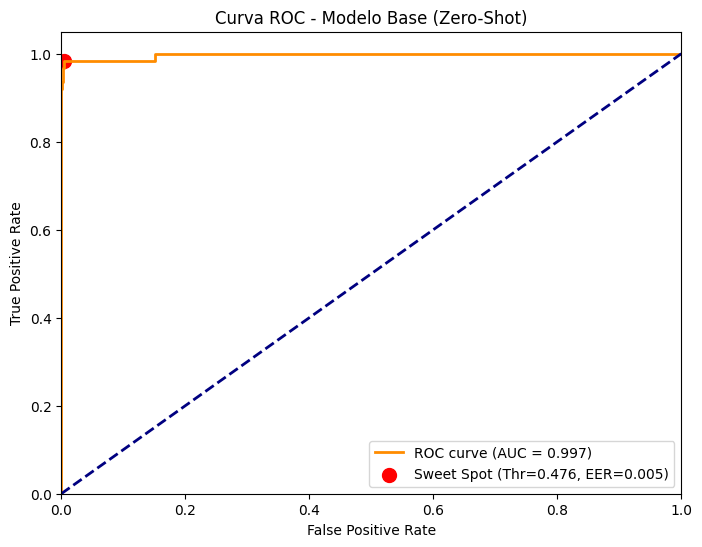

Calculando Curva ROC para el modelo FINE-TUNED...


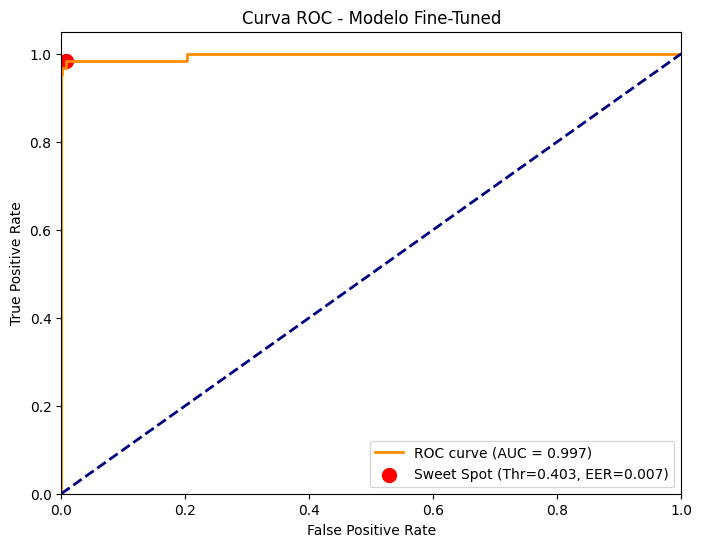

In [24]:
def plot_roc_curve(embeddings, labels, title="Curva ROC"):
    # Calculamos la matriz de similitud coseno completa
    dist_matrix = pairwise_distances(embeddings, metric='cosine')
    sim_matrix = 1 - dist_matrix # Similitud coseno (1 a -1)
    
    y_true = []
    y_scores = []
    
    n = len(labels)
    # Extraemos pares (solo la mitad superior de la matriz para no duplicar)
    for i in range(n):
        for j in range(i+1, n):
            is_same = int(labels[i] == labels[j])
            y_true.append(is_same)
            y_scores.append(sim_matrix[i, j])
            
    # Calculamos FPR, TPR y AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Encontrar el Sweet Spot (Umbral óptimo, EER - Equal Error Rate)
    # Buscamos el punto donde False Positive Rate y False Negative Rate (1-TPR) se cruzan
    fnr = 1 - tpr
    eer_threshold_idx = np.nanargmin(np.absolute((fnr - fpr)))
    opt_threshold = thresholds[eer_threshold_idx]
    eer = fpr[eer_threshold_idx]
    
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.scatter(fpr[eer_threshold_idx], tpr[eer_threshold_idx], color='red', s=100, label=f'Sweet Spot (Thr={opt_threshold:.3f}, EER={eer:.3f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

# Graficar para el modelo Base
print("Calculando Curva ROC para el modelo BASE...")
plot_roc_curve(emb_val_base, y_val_base, title="Curva ROC - Modelo Base (Zero-Shot)")

# Graficar para el modelo Fine-Tuned
if 'emb_val_ft' in locals():
    print("Calculando Curva ROC para el modelo FINE-TUNED...")
    plot_roc_curve(emb_val_ft, y_val_ft, title="Curva ROC - Modelo Fine-Tuned")


In [25]:
# 1. Convertimos tus embeddings de validación (que ya sacaste antes) a tensores
embeddings_tensor = torch.tensor(emb_val_ft).to(device)
# 2. Los normalizamos (muy importante para Similitud Coseno)
embeddings_norm = F.normalize(embeddings_tensor, p=2, dim=1)
# 3. Obtenemos los pesos de TU capa final (tus 70 identidades)
# En la librería facenet-pytorch la capa final se llama 'logits'
class_weights = model.logits.weight
weights_norm = F.normalize(class_weights, p=2, dim=1)
# 4. Calculamos la similitud coseno pura (producto punto)
cosine_sim = F.linear(embeddings_norm, weights_norm)
# 5. La predicción es el índice con mayor similitud
_, predicted = torch.max(cosine_sim, 1)
y_pred_ft_directo = predicted.cpu().numpy()
# 6. Imprimimos el reporte con los nombres reales
etiquetas_presentes = np.unique(np.concatenate((y_val_ft, y_pred_ft_directo)))
nombres = [nombres_total[i] for i in etiquetas_presentes]

print(classification_report(y_val_ft, y_pred_ft_directo, labels=etiquetas_presentes, target_names=nombres))

                           precision    recall  f1-score   support

         Alejandro Toledo       1.00      1.00      1.00         2
             Alvaro Uribe       1.00      1.00      1.00         2
          Amelie Mauresmo       1.00      1.00      1.00         2
             Andre Agassi       1.00      1.00      1.00         2
           Angelina Jolie       1.00      1.00      1.00         2
             Ariel Sharon       1.00      1.00      1.00         2
    Arnold Schwarzenegger       1.00      1.00      1.00         2
     Atal Bihari Vajpayee       1.00      1.00      1.00         2
             Bill Clinton       1.00      1.00      1.00         2
             Carlos Menem       1.00      1.00      1.00         2
             Colin Powell       1.00      1.00      1.00         2
            David Beckham       1.00      1.00      1.00         2
          Donald Rumsfeld       1.00      1.00      1.00         2
         George Robertson       1.00      1.00      1.00     

In [27]:
#Hacemos PCA para bajar de 512 a 50 dimensiones 
pca = PCA(n_components=min(50, len(emb_val_ft))) 
emb_pca = pca.fit_transform(emb_val_ft)
#Aplicamos t-SNE para bajar de 50 a 2 dimensiones 
tsne = TSNE(n_components=2, random_state=42, perplexity=35)
emb_2d = tsne.fit_transform(emb_pca)
#Mapeamos cada vector a su nombre real para el cuadro de diálogo flotante
nombres_reales = [nombres_total[i] for i in y_val_ft]
#Creamos un DataFrame con 2 coordenadas
df = pd.DataFrame({
    'Eje_X': emb_2d[:, 0],
    'Eje_Y': emb_2d[:, 1],
    'Persona': nombres_reales
})
#Creamos el gráfico interactivo 2D
fig = px.scatter(
    df, x='Eje_X', y='Eje_Y', 
    color='Persona',    
    hover_name='Persona',    
    title="Visualización Interactiva 2D de Embeddings (PCA + t-SNE)"
)

fig.update_traces(marker=dict(size=6, opacity=0.8))
fig.update_layout(showlegend=False)
fig.show()

La visualización 2D mediante PCA y t-SNE muestra una clara separación entre los distintos clusters de rostros, lo que sugiere que los embeddings generados capturan adecuadamente las diferencias entre clases. Esto se ve respaldado por las métricas mostradas anteriormente. Solo se observan leves desviaciones en casos puntuales (por ejemplo Jose María Aznar y Winona Ryder), lo que indica que, aunque la separación no es absolutamente perfecta, el rendimiento general es muy bueno.
En conjunto, la visualización y las métricas confirman que los embeddings fueron generados de forma correcta y permiten una clasificación robusta de los distintos rostros.

### Verificación 1:1

La verificación 1:1 compara dos caras y responde: ¿son la misma persona?

Para medir qué tan bueno es un modelo en tareas 1:1, se construyen conjuntos de **Pares Positivos** (dos imágenes de la misma persona) y **Pares Negativos** (dos imágenes de distintas personas). 

El rendimiento se visualiza a través de:
* **Distribución de Similitudes:** Histogramas que muestran qué tan separadas están las poblaciones de pares positivos (campana verde) y negativos (campana roja).
* **Curva ROC y AUC:** Se mide el compromiso entre la Tasa de Falsos Positivos y la Tasa de Verdaderos Positivos a través de múltiples umbrales. Un AUC cercano a 1.0 implica una separación perfecta en el espacio de embeddings

In [28]:
np.random.seed(42)

umbral_str = os.getenv("SIMILARITY_THRESHOLD", "0.55")
umbral_optimo = float(umbral_str)
etiquetas = y_val_ft
embeddings = emb_val_ft
NOMBRES = nombres_total
embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
# Pares POSITIVOS: dos imágenes de la misma persona
pares_pos = []
for persona_id in range(len(NOMBRES)):
    idxs = np.where(etiquetas == persona_id)[0]
    if len(idxs) >= 2:
        # Generamos hasta 10 pares aleatorios por persona
        # Usamos min() para no pasarnos si la persona tiene pocas fotos en validación
        num_pares = min(10, len(idxs) * (len(idxs) - 1) // 2)
        
        # Para evitar bucles infinitos o errores si hay pocas fotos, sacamos combinaciones únicas
        pares_generados = set()
        intentos = 0
        while len(pares_generados) < num_pares and intentos < 50:
            i, j = np.random.choice(idxs, 2, replace=False)
            # Ordenamos para que (i,j) sea lo mismo que (j,i)
            par = tuple(sorted([i, j]))
            pares_generados.add(par)
            intentos += 1
            
        pares_pos.extend(list(pares_generados))

# Pares NEGATIVOS: dos imágenes de personas distintas
pares_neg = []
ids_personas = list(range(len(NOMBRES)))

# Creamos exactamente la misma cantidad de pares negativos que de positivos
for _ in range(len(pares_pos)):
    p1, p2 = np.random.choice(ids_personas, 2, replace=False)
    
    # Buscamos índices válidos para p1 y p2
    idxs_p1 = np.where(etiquetas == p1)[0]
    idxs_p2 = np.where(etiquetas == p2)[0]
    
    # Si alguna de las dos personas no tiene fotos en validación, reintentamos
    while len(idxs_p1) == 0 or len(idxs_p2) == 0:
        p1, p2 = np.random.choice(ids_personas, 2, replace=False)
        idxs_p1 = np.where(etiquetas == p1)[0]
        idxs_p2 = np.where(etiquetas == p2)[0]
        
    i = np.random.choice(idxs_p1)
    j = np.random.choice(idxs_p2)
    pares_neg.append((i, j))

print(f"Pares positivos (misma persona): {len(pares_pos)}")
print(f"Pares negativos (distinta persona): {len(pares_neg)}")

# --- 2. Calcular similitudes (Producto Punto) ---
sims_pos = [np.dot(embeddings[i], embeddings[j]) for i, j in pares_pos]
sims_neg = [np.dot(embeddings[i], embeddings[j]) for i, j in pares_neg]

print(f"\nSimilitud positivos — media: {np.mean(sims_pos):.3f}, min: {np.min(sims_pos):.3f}, max: {np.max(sims_pos):.3f}")
print(f"Similitud negativos — media: {np.mean(sims_neg):.3f}, min: {np.min(sims_neg):.3f}, max: {np.max(sims_neg):.3f}")

Pares positivos (misma persona): 62
Pares negativos (distinta persona): 62

Similitud positivos — media: 0.749, min: 0.129, max: 0.917
Similitud negativos — media: -0.000, min: -0.294, max: 0.345


In [29]:
def obtener_imagen(idx):
    tensor_img, _ = val_loader.dataset[idx]
    
    # Convertir tensor de PyTorch a formato numpy para matplotlib y desnormalizar
    img_np = tensor_img.permute(1, 2, 0).cpu().numpy()
    if img_np.min() < 0:
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
        
    return np.clip(img_np, 0, 1)

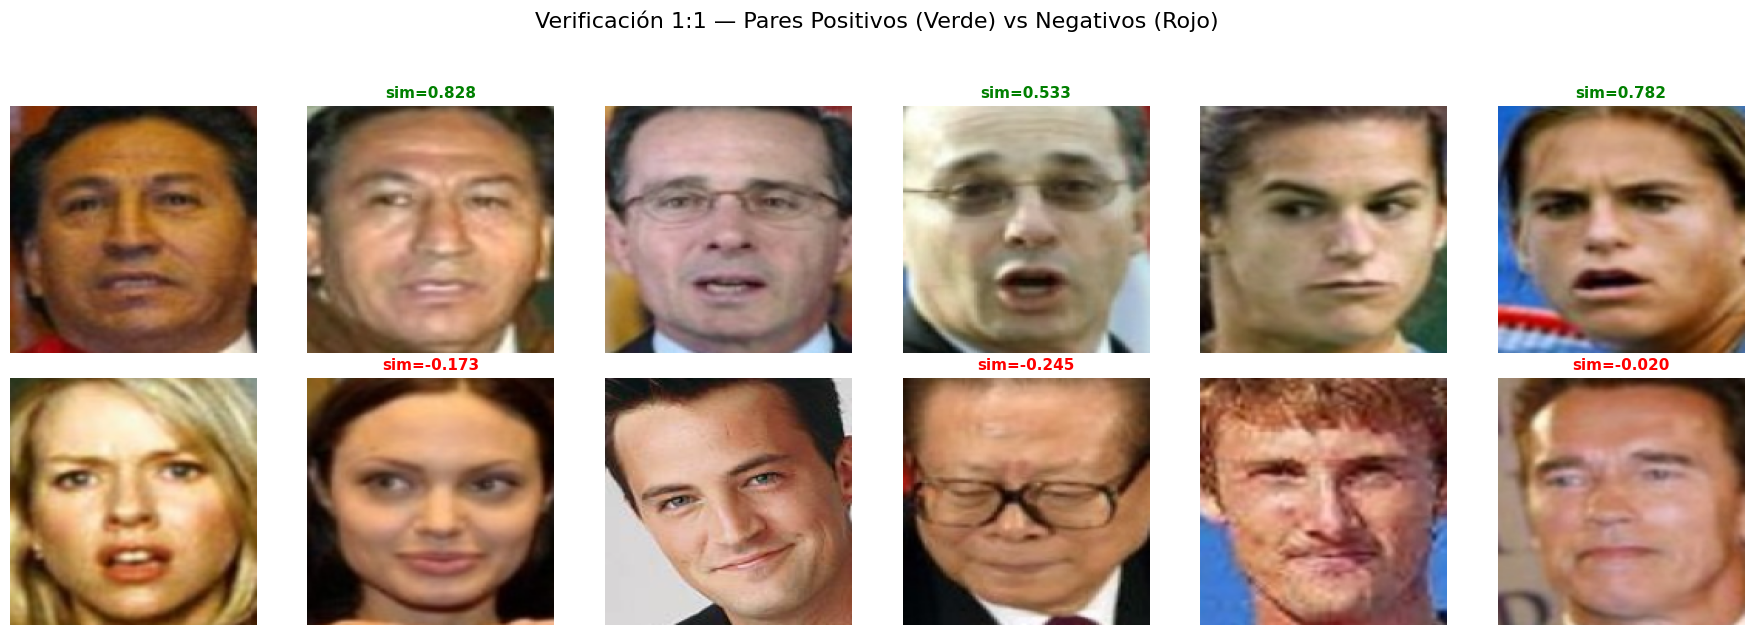

In [30]:
# Visualizar algunos pares
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

# Fila 0: pares positivos
for j in range(3):
    i1, i2 = pares_pos[j]
    sim = np.dot(embeddings[i1], embeddings[i2])
    
    img1 = obtener_imagen(i1)
    img2 = obtener_imagen(i2)
    
    axes[0, j*2].imshow(img1)
    axes[0, j*2].axis("off")
    axes[0, j*2+1].imshow(img2)
    axes[0, j*2+1].set_title(f"sim={sim:.3f}", fontsize=11, color='green', fontweight='bold')
    axes[0, j*2+1].axis("off")

# Fila 1: pares negativos
for j in range(3):
    i1, i2 = pares_neg[j]
    sim = np.dot(embeddings[i1], embeddings[i2])
    
    img1 = obtener_imagen(i1)
    img2 = obtener_imagen(i2)
    
    axes[1, j*2].imshow(img1)
    axes[1, j*2].axis("off")
    axes[1, j*2+1].imshow(img2)
    axes[1, j*2+1].set_title(f"sim={sim:.3f}", fontsize=11, color='red', fontweight='bold')
    axes[1, j*2+1].axis("off")

axes[0, 0].set_ylabel("Misma\npersona", fontsize=12, rotation=0, labelpad=50, va="center", color='green', fontweight='bold')
axes[1, 0].set_ylabel("Distinta\npersona", fontsize=12, rotation=0, labelpad=50, va="center", color='red', fontweight='bold')
plt.suptitle("Verificación 1:1 — Pares Positivos (Verde) vs Negativos (Rojo)", y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

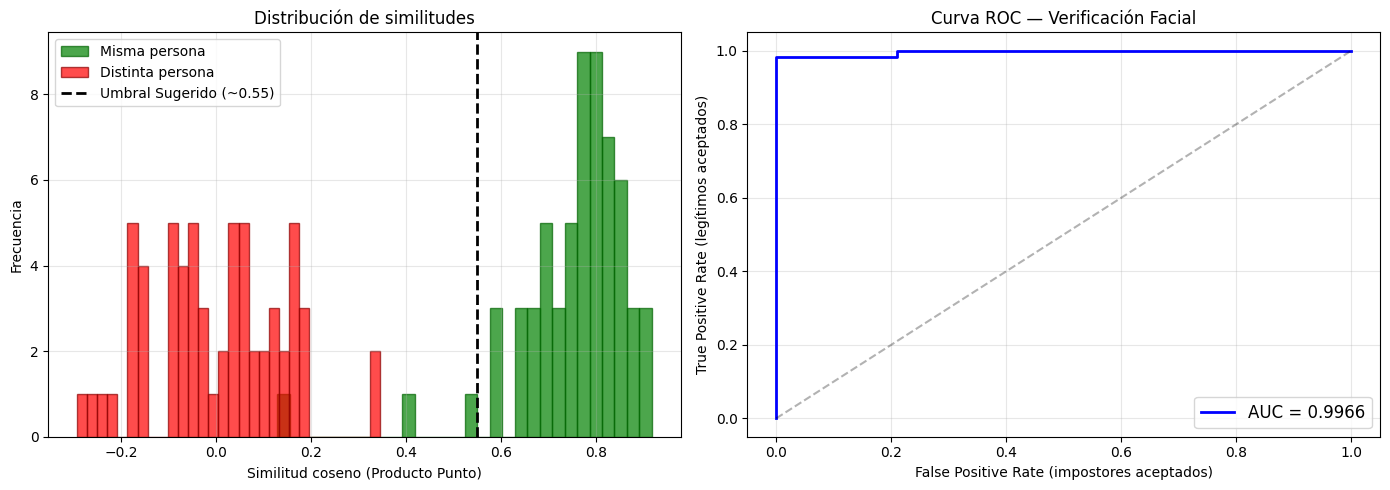

AUC (Área Bajo la Curva): 0.9966

Interpretación:
  AUC = 1.0 -> Separación perfecta entre positivos y negativos (Modelo Ideal)
  AUC = 0.5 -> Modelo random (No distingue nada)
  Cuanto menos se solapen las distribuciones roja y verde, mejor funciona tu modelo InceptionResnetV1.


In [31]:
# Histograma de similitudes y Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(sims_pos, bins=30, alpha=0.7, label='Misma persona', color='green', edgecolor='darkgreen')
axes[0].hist(sims_neg, bins=30, alpha=0.7, label='Distinta persona', color='red', edgecolor='darkred')
hist_pos, bins_pos = np.histogram(sims_pos, bins=50, density=True)
hist_neg, bins_neg = np.histogram(sims_neg, bins=50, density=True)
axes[0].axvline(x=umbral_optimo, color='black', linestyle='--', linewidth=2, label=f'Umbral Sugerido (~{umbral_optimo})')


axes[0].set_xlabel('Similitud coseno (Producto Punto)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de similitudes')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Curva ROC
y_true = [1] * len(sims_pos) + [0] * len(sims_neg)
y_scores = sims_pos + sims_neg
fpr, tpr, umbrales = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate (impostores aceptados)')
axes[1].set_ylabel('True Positive Rate (legítimos aceptados)')
axes[1].set_title('Curva ROC — Verificación Facial')
axes[1].legend(fontsize=12, loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AUC (Área Bajo la Curva): {roc_auc:.4f}")
print(f"\nInterpretación:")
print(f"  AUC = 1.0 -> Separación perfecta entre positivos y negativos (Modelo Ideal)")
print(f"  AUC = 0.5 -> Modelo random (No distingue nada)")
print(f"  Cuanto menos se solapen las distribuciones roja y verde, mejor funciona tu modelo InceptionResnetV1.")

### Identificación 1:N

La identificación 1:N busca quién es una persona dentro de una galería de identidades conocidas

A diferencia de la verificación 1:1, que responde a la pregunta ¿son la misma persona?, la identificación 1:N responde a la pregunta ¿Quién es esta persona?. 

En base a un conjunto de embedings de personas conocidas se recibe una consulta (query) se extrae su embeding y se calcula su similitud contra todos los embedings del conjunto.

Como métrica para la identificación 1:N se usa el Rank-1 Accuracy (o Top-1 Accuracy). Esta métrica calcula el porcentaje de veces que la identidad correcta de la imagen (Query) aparece en la primera posición de los resultados devueltos por la Galería. 


In [32]:
np.random.seed(42)

etiquetas = y_val_ft
embeddings = emb_val_ft
NOMBRES = nombres_total

# Aseguramos normalización L2
embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
gal_embs, gal_labels, gal_idxs = [], [], []
qry_embs, qry_labels, qry_idxs = [], [], []

for persona_id in range(len(NOMBRES)):
    idxs = np.where(etiquetas == persona_id)[0].copy()
    
    # Solo procesamos si la persona tiene al menos 2 imágenes (1 para galería, 1 para query)
    if len(idxs) >= 2:
        np.random.shuffle(idxs)
        n_gal = max(1, min(10, len(idxs) - 2)) 

        for idx in idxs[:n_gal]:
            gal_embs.append(embeddings[idx])
            gal_labels.append(persona_id)
            gal_idxs.append(idx) # Guardamos el índice original para la imagen

        for idx in idxs[n_gal:]:
            qry_embs.append(embeddings[idx])
            qry_labels.append(persona_id)
            qry_idxs.append(idx)

gal_embs = np.array(gal_embs)
gal_labels = np.array(gal_labels)
qry_embs = np.array(qry_embs)
qry_labels = np.array(qry_labels)

print(f"Galería: {len(gal_embs)} embeddings (Base de Datos)")
print(f"Consultas: {len(qry_embs)} embeddings (Imágenes de prueba)")

# Identificación 1:N
# Similitud coseno en batch: producto punto de matrices
sims_matrix = qry_embs @ gal_embs.T  # (n_queries, n_galeria)

# Rank-1: el índice de galería más similar para cada query
best_match_idx = sims_matrix.argmax(axis=1)
predicciones = gal_labels[best_match_idx]

# Accuracy General
accuracy_r1 = (predicciones == qry_labels).mean()

print(f"\nAccuracy Rank-1 General: {accuracy_r1*100:.2f}% ({(predicciones == qry_labels).sum()}/{len(qry_labels)} aciertos)")
print(f"\nAccuracy Rank-1 por persona:")

for persona_id, nombre in enumerate(NOMBRES):
    mask = qry_labels == persona_id
    if mask.sum() > 0:
        acc = (predicciones[mask] == persona_id).mean()
        print(f"  {nombre}: {acc*100:.1f}% ({(predicciones[mask] == persona_id).sum()}/{mask.sum()})")

Galería: 62 embeddings (Base de Datos)
Consultas: 62 embeddings (Imágenes de prueba)

Accuracy Rank-1 General: 96.77% (60/62 aciertos)

Accuracy Rank-1 por persona:
  Alejandro Toledo: 100.0% (1/1)
  Alvaro Uribe: 0.0% (0/1)
  Amelie Mauresmo: 100.0% (1/1)
  Andre Agassi: 100.0% (1/1)
  Angelina Jolie: 100.0% (1/1)
  Ariel Sharon: 100.0% (1/1)
  Arnold Schwarzenegger: 100.0% (1/1)
  Atal Bihari Vajpayee: 100.0% (1/1)
  Bill Clinton: 100.0% (1/1)
  Carlos Menem: 100.0% (1/1)
  Colin Powell: 100.0% (1/1)
  David Beckham: 100.0% (1/1)
  Donald Rumsfeld: 100.0% (1/1)
  George Robertson: 100.0% (1/1)
  George W Bush: 100.0% (1/1)
  Gerhard Schroeder: 100.0% (1/1)
  Gloria Macapagal Arroyo: 100.0% (1/1)
  Gray Davis: 100.0% (1/1)
  Guillermo Coria: 100.0% (1/1)
  Hamid Karzai: 100.0% (1/1)
  Hans Blix: 100.0% (1/1)
  Hugo Chavez: 100.0% (1/1)
  Igor Ivanov: 100.0% (1/1)
  Jack Straw: 100.0% (1/1)
  Jacques Chirac: 100.0% (1/1)
  Jean Chretien: 100.0% (1/1)
  Jennifer Aniston: 100.0% (1/1)
  

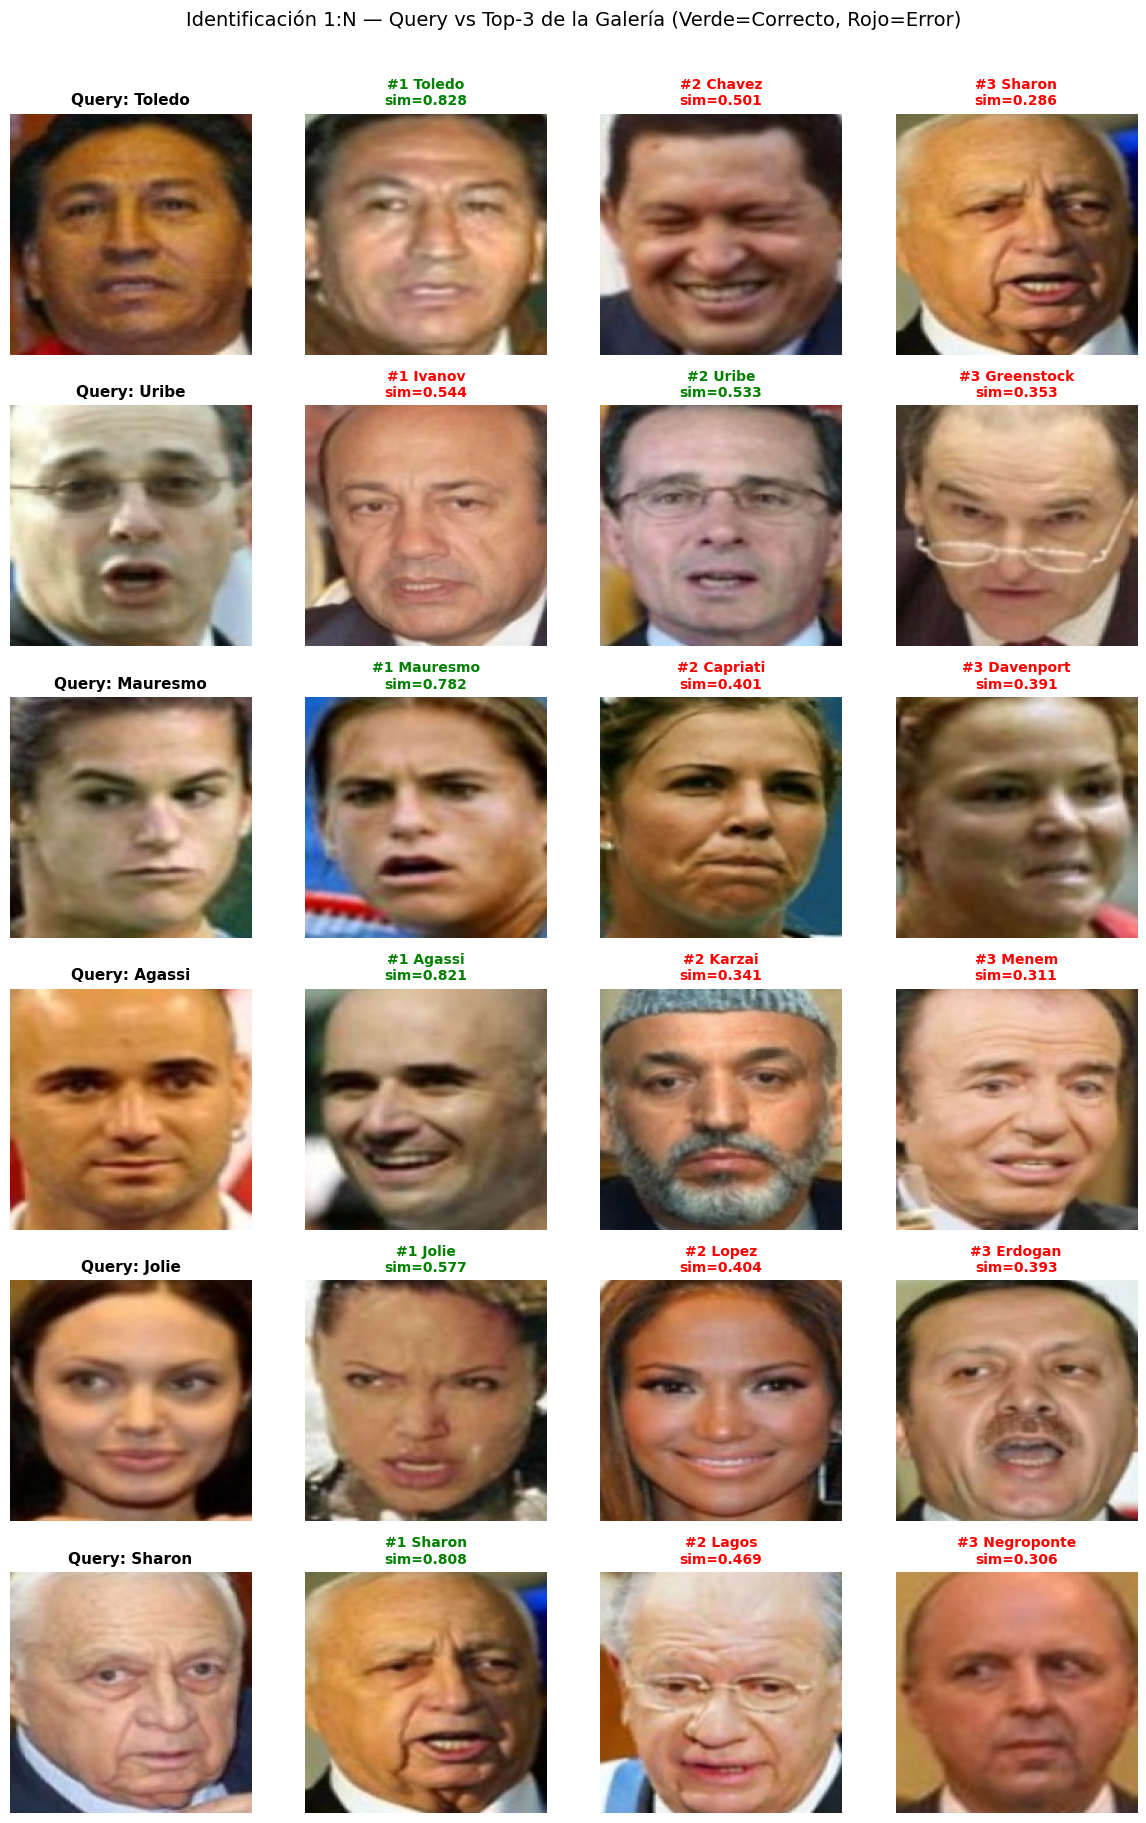

In [33]:
# Resultados de identificación: query + top-3 
n_show = min(6, len(qry_embs))
fig, axes = plt.subplots(n_show, 4, figsize=(12, 3 * n_show))

# Elegir queries variados
show_idxs = []
for persona_id in range(len(NOMBRES)):
    candidatos = np.where(qry_labels == persona_id)[0]
    if len(candidatos) > 0:
        show_idxs.append(candidatos[0])
show_idxs = show_idxs[:n_show]

for row, q_idx in enumerate(show_idxs):
    # Obtenemos los 3 índices de galería con mayor similitud
    top3 = sims_matrix[q_idx].argsort()[::-1][:3]

    # Columna 0: query
    img_query = obtener_imagen(qry_idxs[q_idx])
    axes[row, 0].imshow(img_query)
    nombre_query = NOMBRES[qry_labels[q_idx]].split()[-1]
    axes[row, 0].set_title(f"Query: {nombre_query}", fontsize=11, fontweight='bold')
    axes[row, 0].axis("off")

    # Columnas 1-3: top-3 de la galería
    for j, match_idx in enumerate(top3):
        correcto = gal_labels[match_idx] == qry_labels[q_idx]
        color = "green" if correcto else "red"
        sim_val = sims_matrix[q_idx, match_idx]

        img_galeria = obtener_imagen(gal_idxs[match_idx])
        axes[row, j + 1].imshow(img_galeria)
        
        nombre_gal = NOMBRES[gal_labels[match_idx]].split()[-1]
        axes[row, j + 1].set_title(
            f"#{j+1} {nombre_gal}\nsim={sim_val:.3f}",
            fontsize=10, color=color, fontweight='bold'
        )
        axes[row, j + 1].axis("off")

plt.suptitle("Identificación 1:N — Query vs Top-3 de la Galería (Verde=Correcto, Rojo=Error)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def visualizar_aumentos_dataset(transformacion, num_imagenes=3, num_variaciones=4):
    """
    Toma imágenes al azar del dataset y muestra los efectos del data augmentation.
    
    Parámetros:
    - transformacion: El pipeline de albumentations.
    - num_imagenes: Cuántas imágenes originales distintas se van a evaluar.
    - num_variaciones: Cuántas versiones aumentadas generar por cada original.
    """
    data_path = os.getenv("DATA_AUGMENTATION_PATH")
    
    if not data_path or not os.path.exists(data_path):
        print("Error: La ruta obtenida de 'DATA_AUGMENTATION_PATH' no es válida o no existe.")
        print(f"Ruta actual detectada: {data_path}")
        return
        
    imagenes_validas = []
    for root, _, files in os.walk(data_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp')):
                imagenes_validas.append(os.path.join(root, file))
                
    if not imagenes_validas:
        print(f"No se encontraron imágenes en la ruta: {data_path}")
        return
        
    # Selección de imágenes al azar
    num_seleccionar = min(num_imagenes, len(imagenes_validas))
    imagenes_seleccionadas = random.sample(imagenes_validas, num_seleccionar)
    
    # Grilla de visualización
    fig, axes = plt.subplots(num_seleccionar, num_variaciones + 1, figsize=(15, 4 * num_seleccionar))
    
    # Si solo hay 1 fila, matplotlib devuelve un arreglo 1D, lo convertimos a 2D
    if num_seleccionar == 1:
        axes = [axes]
        
    # 5. Graficación
    for fila, img_path in enumerate(imagenes_seleccionadas):
        # Leer imagen y convertir de BGR a RGB
        img_original = cv2.imread(img_path)
        img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
        
        # Imagen Original
        axes[fila][0].imshow(img_original)
        axes[fila][0].set_title(f"Original\n({os.path.basename(img_path)})", fontweight='bold', fontsize=10)
        axes[fila][0].axis("off")
        
        # Variaciones aumentadas
        for col in range(1, num_variaciones + 1):
            # Transformaciones de Albumentations
            aumentada = transformacion(image=img_original)["image"]
            # Formatear el tensor a formato de imagen si es necesario
            if hasattr(aumentada, 'numpy'): 
                aumentada = aumentada.permute(1, 2, 0).numpy()
            # Evitar problemas de visualización con flotantes
            if aumentada.dtype in [np.float32, np.float64]:
                aumentada = np.clip(aumentada, 0, 1)
                
            axes[fila][col].imshow(aumentada)
            axes[fila][col].set_title(f"Variación {col}", fontsize=10)
            axes[fila][col].axis("off")
            
    plt.tight_layout()
    plt.show()

#### Resultados del Data Augmentation

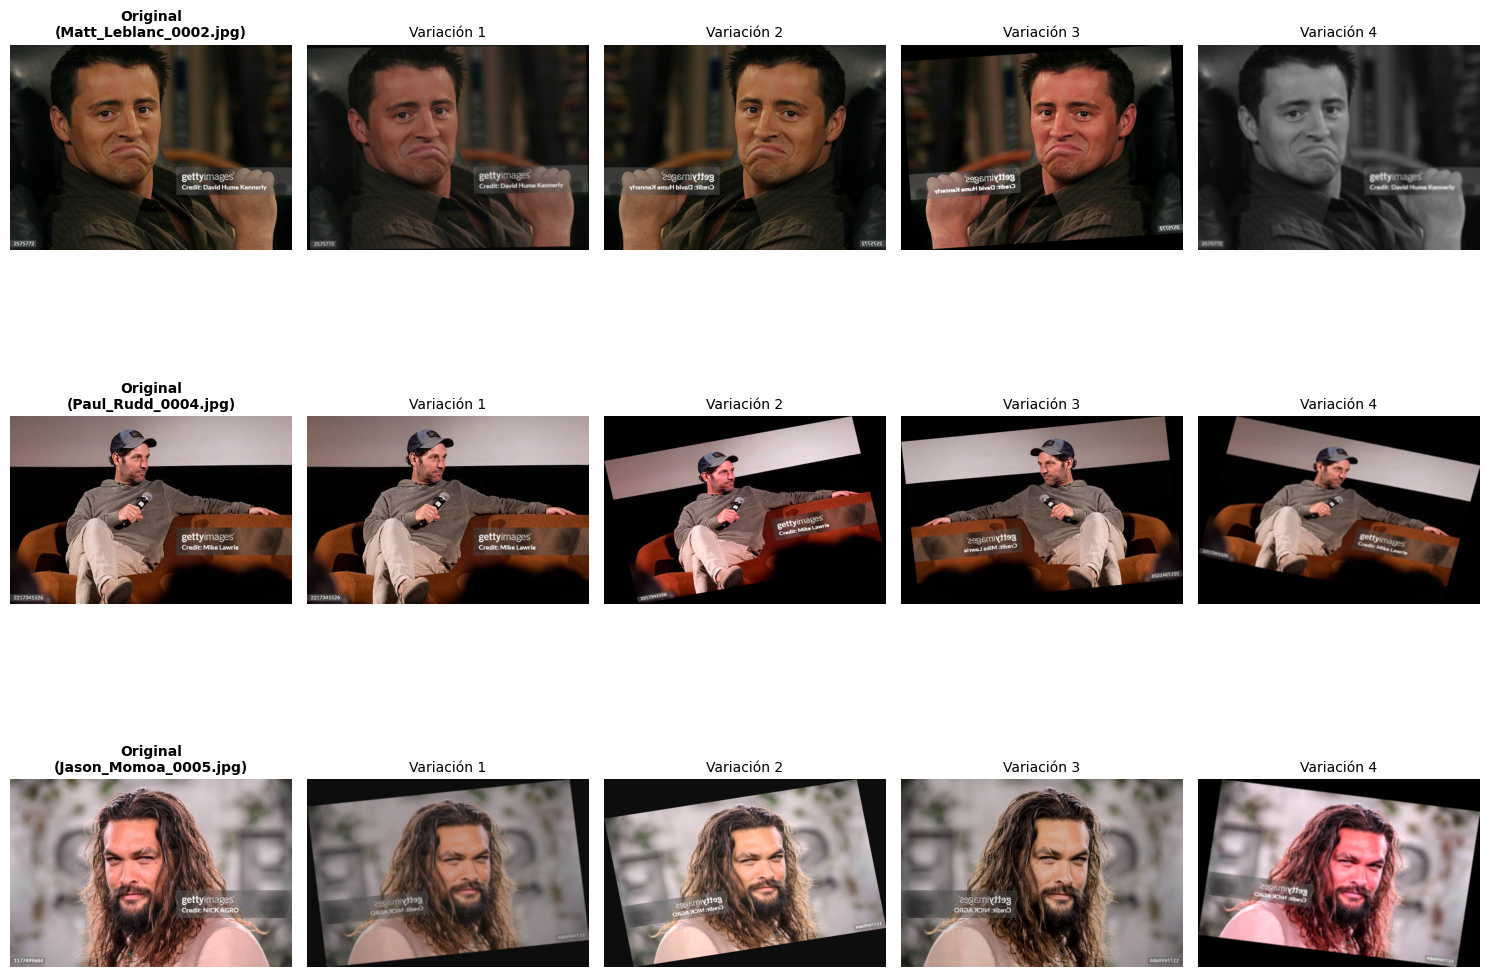

In [40]:
visualizar_aumentos_dataset(augmenter_albumentations, num_imagenes=3, num_variaciones=4)